#### Look Before You Leap (LBYL), или «Cначала проверь, потом действуй»
Минус LBYL здесь: Между проверкой os.path.exists и открытием файла другой процесс может удалить этот файл. Произойдет сбой (состояние гонки).

In [ ]:
import os

user_info = {"name": "Алексей"}

# 1
if "age" in user_info:
    print(user_info["age"])
else:
    print("Возраст не указан")



# 2
filename = "data.txt"
# Проверяем, существует ли файл, прежде чем открыть
if os.path.exists(filename):
    with open(filename, "r") as f:
        print(f.read())
else:
    print("Файл не найден")


# 3
def divide_lbyl(a, b):
    if b == 0:
        return "Деление на ноль невозможно"
    return a / b

#### Easier to Ask Forgiveness than Permission (EAFP), или «Проще попросить прощения, чем разрешения»

In [ ]:
user_info = {"name": "Алексей"}


# 1
# Сразу пытаемся взять значение и ловим ошибку, если ключа нет
try:
    print(user_info["age"])
except KeyError:
    print("Возраст не указан")


# 2
filename = "data.txt"
# Сразу открываем. Если файла нет — обрабатываем исключение
try:
    with open(filename, "r") as f:
        print(f.read())
except FileNotFoundError:
    print("Файл не найден")


# 3
def divide_eafp(a, b):
    try:
        return a / b
    except ZeroDivisionError:
        return "Деление на ноль невозможно"

#### Правильный порядок

In [ ]:
try:
    print(1 / int(input()))
except ZeroDivisionError:
    print("Ошибка деления на ноль.")
except ValueError:
    print("Невозможно преобразовать строку в число.")
except Exception:
    print("Неизвестная ошибка.")
else:
    print("Операция выполнена успешно.")
finally:
    print("Программа завершена.")


#### Ручное исключение

In [ ]:
x = int(input("Введите число: "))

if x < 0:
    raise ValueError("Число должно быть положительным")

#### Иерархия исключений в Python

Исключения — это классы, а значит, вы можете не только использовать встроенные, но и создавать собственные. Такие классы могут наследоваться от Exception или любого другого подходящего базового исключения.

Исключения в Python являются объектами классов ошибок. Сами классы исключений организованы в иерархию, где все стандартные исключения наследуются от базового класса BaseException. Благодаря этому механизму можно группировать исключения и обрабатывать их гибко и последовательно.

В документации Python версии 3.10.8 приводится следующее дерево иерархии стандартных исключений:

BaseException
+-- SystemExit
+-- KeyboardInterrupt
+-- GeneratorExit
+-- Exception
+-- StopIteration
+-- StopAsyncIteration
+-- ArithmeticError
| +-- FloatingPointError
| +-- OverflowError
| +-- ZeroDivisionError
+-- AssertionError
+-- AttributeError
+-- BufferError
+-- EOFError
+-- ImportError
| +-- ModuleNotFoundError
+-- LookupError
| +-- IndexError
| +-- KeyError
+-- MemoryError
+-- NameError
| +-- UnboundLocalError
+-- OSError
| +-- BlockingIOError
| +-- ChildProcessError
| +-- ConnectionError
| | +-- BrokenPipeError
| | +-- ConnectionAbortedError
| | +-- ConnectionRefusedError
| | +-- ConnectionResetError
| +-- FileExistsError
| +-- FileNotFoundError
| +-- InterruptedError
| +-- IsADirectoryError
| +-- NotADirectoryError
| +-- PermissionError
| +-- ProcessLookupError
| +-- TimeoutError
+-- ReferenceError
+-- RuntimeError
| +-- NotImplementedError
| +-- RecursionError
+-- SyntaxError
| +-- IndentationError
| +-- TabError
+-- SystemError
+-- TypeError
+-- ValueError
| +-- UnicodeError
| +-- UnicodeDecodeError
| +-- UnicodeEncodeError
| +-- UnicodeTranslateError
+-- Warning
+-- DeprecationWarning
+-- PendingDeprecationWarning
+-- RuntimeWarning
+-- SyntaxWarning
+-- UserWarning
+-- FutureWarning
+-- ImportWarning
+-- UnicodeWarning
+-- BytesWarning
+-- EncodingWarning
+-- ResourceWarning

### Создание собственных исключений

In [ ]:
class NumbersError(Exception):
    pass

class EvenError(NumbersError):
    pass

class NegativeError(NumbersError):
    pass

def no_even(numbers):
    if all(x % 2 != 0 for x in numbers):
        return True
    raise EvenError("В списке не должно быть чётных чисел")

def no_negative(numbers):
    if all(x >= 0 for x in numbers):
        return True
    raise NegativeError("В списке не должно быть отрицательных чисел")

def main():
    print("Введите числа в одну строку через пробел:")
    try:
        numbers = [int(x) for x in input().split()]
        if no_negative(numbers) and no_even(numbers):
            print(f"Сумма чисел равна: {sum(numbers)}.")
    except NumbersError as e:  # Обращение к исключению как к объекту
        print(f"Произошла ошибка: {e}.")
    except Exception as e:
        print(f"Произошла непредвиденная ошибка: {e}.")
  
if __name__ == "__main__":
    main()


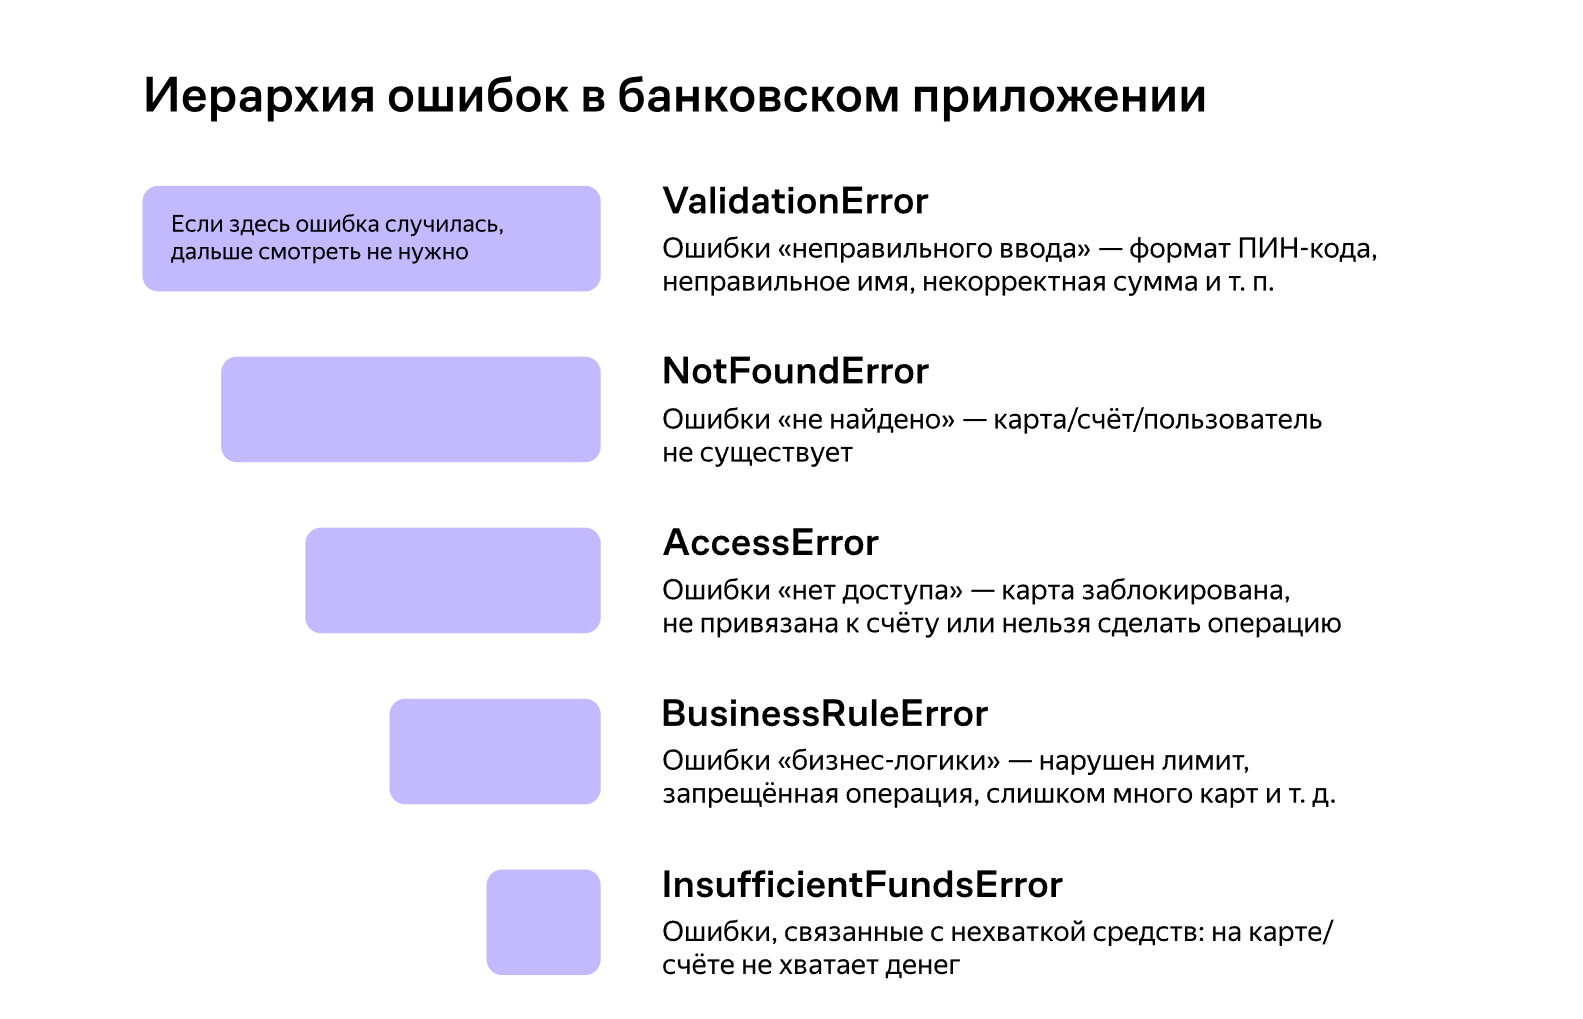

### Что такое модуль и как правильно его импортировать и использовать в других программах  

Конструкция `if __name__ == "__main__"`: — это общепринятый шаблон (паттерн), который пишут вручную для явного обозначения старта программы.

In [ ]:
def hello(name):
    return f"Привет, {name}!"

def main():
    print(hello(input("Введите своё имя: ")))

if __name__ == "__main__":
    main()

При запуске файда создается скрытая переменная `__name__` и Python присваивает ей значение в зависимости от того, как был запущен файл:  
1. **Файл запущен напрямую** присваивает значение `"__main__"`

2. **Файл импортирован** присваивает имя самого файла

Для чего писать `main()`?  
1. Чистота кода: Когда проект разрастается до тысяч строк, глобальные переменные (находящиеся вне функций) начинают путаться и забивать память.  
2. Изоляция: Переменные внутри функции main() локальны — они создаются при вызове и уничтожаются после завершения работы функции.

In [ ]:
import sys

def main():
    # Проверяем аналог argc. 
    # sys.argv[0] — это всегда имя файла, поэтому если длина 1, аргументов нет.
    if len(sys.argv) < 2:
        print("Ошибка: вы не передали имя!")
        print(f"Использование: python {sys.argv[0]} [ваше_имя]")
        return

    # Получаем первый аргумент (аналог argv[1])
    name = sys.argv[1]
    print(f"Привет, {name}!")

if __name__ == "__main__":
    main()
# python script.py
# python script.py Сергей

### Классный прямоугольник

In [30]:
class Rectangle:
    def __init__(self, first, second):
        (x1, y1), (x2, y2) = first, second
        x1, x2 = sorted((x1, x2))
        y1, y2 = sorted((y1, y2))
        self.x1, self.y1 = x1, y1
        self.x2, self.y2 = x2, y2
        self.width, self.height = round(x2 - x1, 2), round(y2 - y1, 2)

    def perimeter(self):
        return round((self.width + self.height) * 2, 2)
    
    def area(self):
        return round(self.width * self.height, 2)
    
    def get_pos(self):
        # Левый верхний угол (минимальный x и максимальный y)
        return (round(self.x1, 2), round(self.y2, 2))
    
    def get_size(self):
        return (round(self.width, 2), round(self.height, 2))
    
    def move(self, dx, dy):
        self.x1 = round(self.x1 + dx, 2)
        self.x2 = round(self.x2 + dx, 2)
        self.y1 = round(self.y1 + dy, 2)
        self.y2 = round(self.y2 + dy, 2)
    
    def resize(self, width, height):
        self.width = round(width, 2)
        self.height = round(height, 2)
        self.x2 = round(self.x1 + self.width, 2)
        self.y1 = round(self.y2 - self.height, 2)
    
    def turn(self):
        # 1. Находим центр
        cx = (self.x1 + self.x2) / 2
        cy = (self.y1 + self.y2) / 2

        # 2. Поворот на 90 градусов меняет ширину и высоту местами
        self.width, self.height = self.height, self.width

        # 3. Пересчитываем границы относительно центра с округлением
        self.x1 = round(cx - self.width / 2, 2)
        self.x2 = round(cx + self.width / 2, 2)
        self.y1 = round(cy - self.height / 2, 2)
        self.y2 = round(cy + self.height / 2, 2)

    def scale(self, factor):
        # 1. Находим центр
        cx = (self.x1 + self.x2) / 2
        cy = (self.y1 + self.y2) / 2

        # 2. Масштабируем стороны
        self.width = round(self.width * factor, 2)
        self.height = round(self.height * factor, 2)

        # 3. Пересчитываем координаты от центра во все стороны
        self.x1 = round(cx - self.width / 2, 2)
        self.x2 = round(cx + self.width / 2, 2)
        self.y1 = round(cy - self.height / 2, 2)
        self.y2 = round(cy + self.height / 2, 2)

rect = Rectangle((3.14, 2.71), (-3.14, -2.71))
print(rect.get_pos(), rect.get_size(), sep='\n')
rect.scale(2.0)
print(rect.get_pos(), rect.get_size(), sep='\n')

(-3.14, 2.71)
(6.28, 5.42)
(-6.28, 5.42)
(12.56, 10.84)


### Шашки

In [1]:
class Cell:
    def __init__(self, state):
        self.state = state

    def status(self):
        return self.state


class Checkers:
    def __init__(self):
        self.board = {}
        # Строки от 1 до 8 (индексы от 0 до 7)
        for r_idx, r in enumerate("12345678"):
            # Столбцы от A до H (индексы от 0 до 7)
            for c_idx, c in enumerate("ABCDEFGH"):
                pos = c + r
                
                # В стандартных шашках игра ведется только на черных клетках.
                # Черные клетки расположены там, где сумма индексов строки и столбца четная.
                if (r_idx + c_idx) % 2 == 0:
                    if r_idx < 3:          # Первые 3 ряда (1, 2, 3) — белые шашки
                        state = 'W'
                    elif r_idx > 4:        # Последние 3 ряда (6, 7, 8) — черные шашки
                        state = 'B'
                    else:                  # Ряды 4 и 5 — пустые клетки
                        state = 'X'
                else:
                    # Белые клетки не участвуют в игре
                    state = 'X'
                
                self.board[pos] = Cell(state)

    def move(self, f, t):
        # Меняем состояние клеток. 
        # Клетка t получает шашку (состояние) из клетки f, а клетка f становится пустой ('X')
        self.board[t].state = self.board[f].state
        self.board[f].state = 'X'

    def get_cell(self, p):
        # Возвращаем объект класса Cell по координатам
        return self.board[p]


checkers = Checkers()
for row in '87654321':
    for col in 'ABCDEFGH':
        print(checkers.get_cell(col + row).status(), end='')
    print()

XBXBXBXB
BXBXBXBX
XBXBXBXB
XXXXXXXX
XXXXXXXX
WXWXWXWX
XWXWXWXW
WXWXWXWX


In [ ]:
class Queue:
    def __init__(self):
        self.items = []

    def push(self, item):
        self.items.append(item)

    def pop(self):
        return self.items.pop(0)

    def is_empty(self):
        return len(self.items) == 0

1
